#House Price Prediction

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df=pd.read_csv("/content/HousingData.csv")

In [32]:
df.head(50)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,NaN,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,NaN,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [33]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [34]:
df.shape

(506, 14)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [36]:
df.duplicated().sum()

np.int64(0)

In [39]:
df['CRIM'].skew()
df['CRIM']=df['CRIM'].fillna(df['CRIM'].median())

In [40]:
df['ZN'].skew()
df['ZN']=df['ZN'].fillna(df['ZN'].median())

In [41]:
df['INDUS'].skew()
df['INDUS']=df['INDUS'].fillna(df['INDUS'].mean())

In [42]:
df['CHAS'].skew()
df['CHAS']=df['CHAS'].fillna(df['CHAS'].median())

In [43]:
df['AGE'].skew()
df['AGE']=df['AGE'].fillna(df['AGE'].mean())

In [44]:
df['LSTAT'].skew()
df['LSTAT']=df['LSTAT'].fillna(df['LSTAT'].median())

In [45]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [46]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.479140,10.768775,11.083992,0.067194,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.664625,22.532806
std,8.570832,23.025124,6.699165,0.250605,0.115878,0.702617,27.439466,2.105710,8.707259,168.537116,2.164946,91.294864,7.017219,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083235,0.000000,5.190000,0.000000,0.449000,5.885500,45.925000,2.100175,4.000000,279.000000,17.400000,375.377500,7.230000,17.025000
50%,0.253715,0.000000,9.900000,0.000000,0.538000,6.208500,74.450000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,2.808720,0.000000,18.100000,0.000000,0.624000,6.623500,93.575000,5.188425,24.000000,666.000000,20.200000,396.225000,16.570000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [70]:
corr=df.corr()
corr.sort_values('MEDV',ascending=False)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
MEDV,-0.383895,0.362292,-0.478657,0.183844,-0.427321,0.695360,-0.380223,0.249929,-0.381626,-0.468536,-0.507787,0.333461,-0.723093,1.000000
RM,-0.220045,0.312295,-0.381457,0.106797,-0.302188,1.000000,-0.241351,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.604323,0.695360
ZN,-0.185359,1.000000,-0.507800,-0.032992,-0.498619,0.312295,-0.534831,0.632428,-0.300061,-0.304385,-0.394622,0.170125,-0.398838,0.362292
B,-0.365336,0.170125,-0.354597,0.050608,-0.380051,0.128069,-0.265282,0.291512,-0.444413,-0.441808,-0.177383,1.000000,-0.370993,0.333461
DIS,-0.366025,0.632428,-0.699639,-0.092318,-0.769230,0.205246,-0.724353,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.483244,0.249929
CHAS,-0.055585,-0.032992,0.054172,1.000000,0.070867,0.106797,0.073549,-0.092318,-0.003339,-0.035822,-0.109451,0.050608,-0.047279,0.183844
AGE,0.346395,-0.534831,0.614592,0.073549,0.711461,-0.241351,1.000000,-0.724353,0.449989,0.500589,0.262723,-0.265282,0.576605,-0.380223
RAD,0.601224,-0.300061,0.593176,-0.003339,0.611441,-0.209847,0.449989,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.467765,-0.381626
CRIM,1.000000,-0.185359,0.392063,-0.055585,0.410971,-0.220045,0.346395,-0.366025,0.601224,0.560469,0.277964,-0.365336,0.437417,-0.383895
NOX,0.410971,-0.498619,0.740965,0.070867,1.000000,-0.302188,0.711461,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.573040,-0.427321


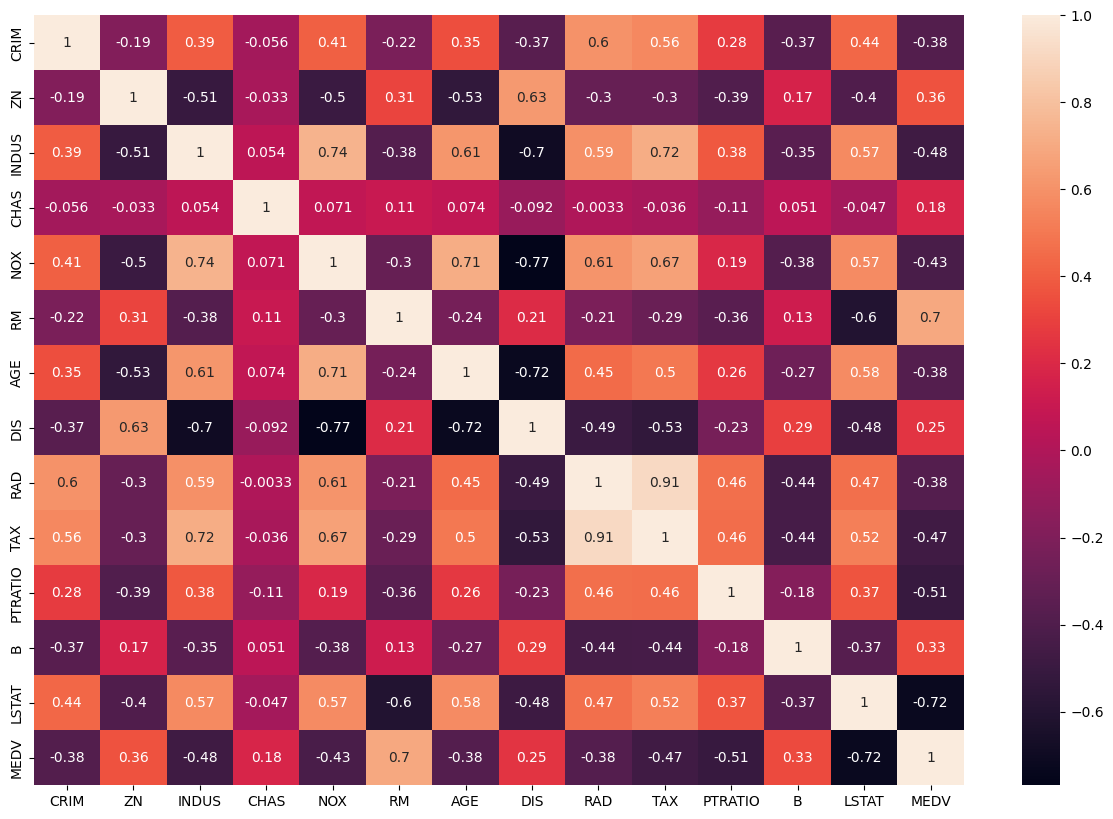

In [121]:
plt.figure(figsize=(15,10))
sns.heatmap(corr,annot=True)
plt.savefig('/content/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

The correlation heatmap shows that RM (0.70) and LSTAT (-0.72) have the strongest correlations with MEDV. RM has a strong positive relationship with house value, while LSTAT has a strong negative relationship. CHAS (0.18) and DIS (0.25) have relatively weak correlations with MEDV. However, low individual correlation does not necessarily mean that a feature is unimportant, as removing DIS resulted in reduced performance for some models. The heatmap also shows strong correlations among some predictor variables, such as RAD and TAX (0.91), indicating possible multicollinearity.

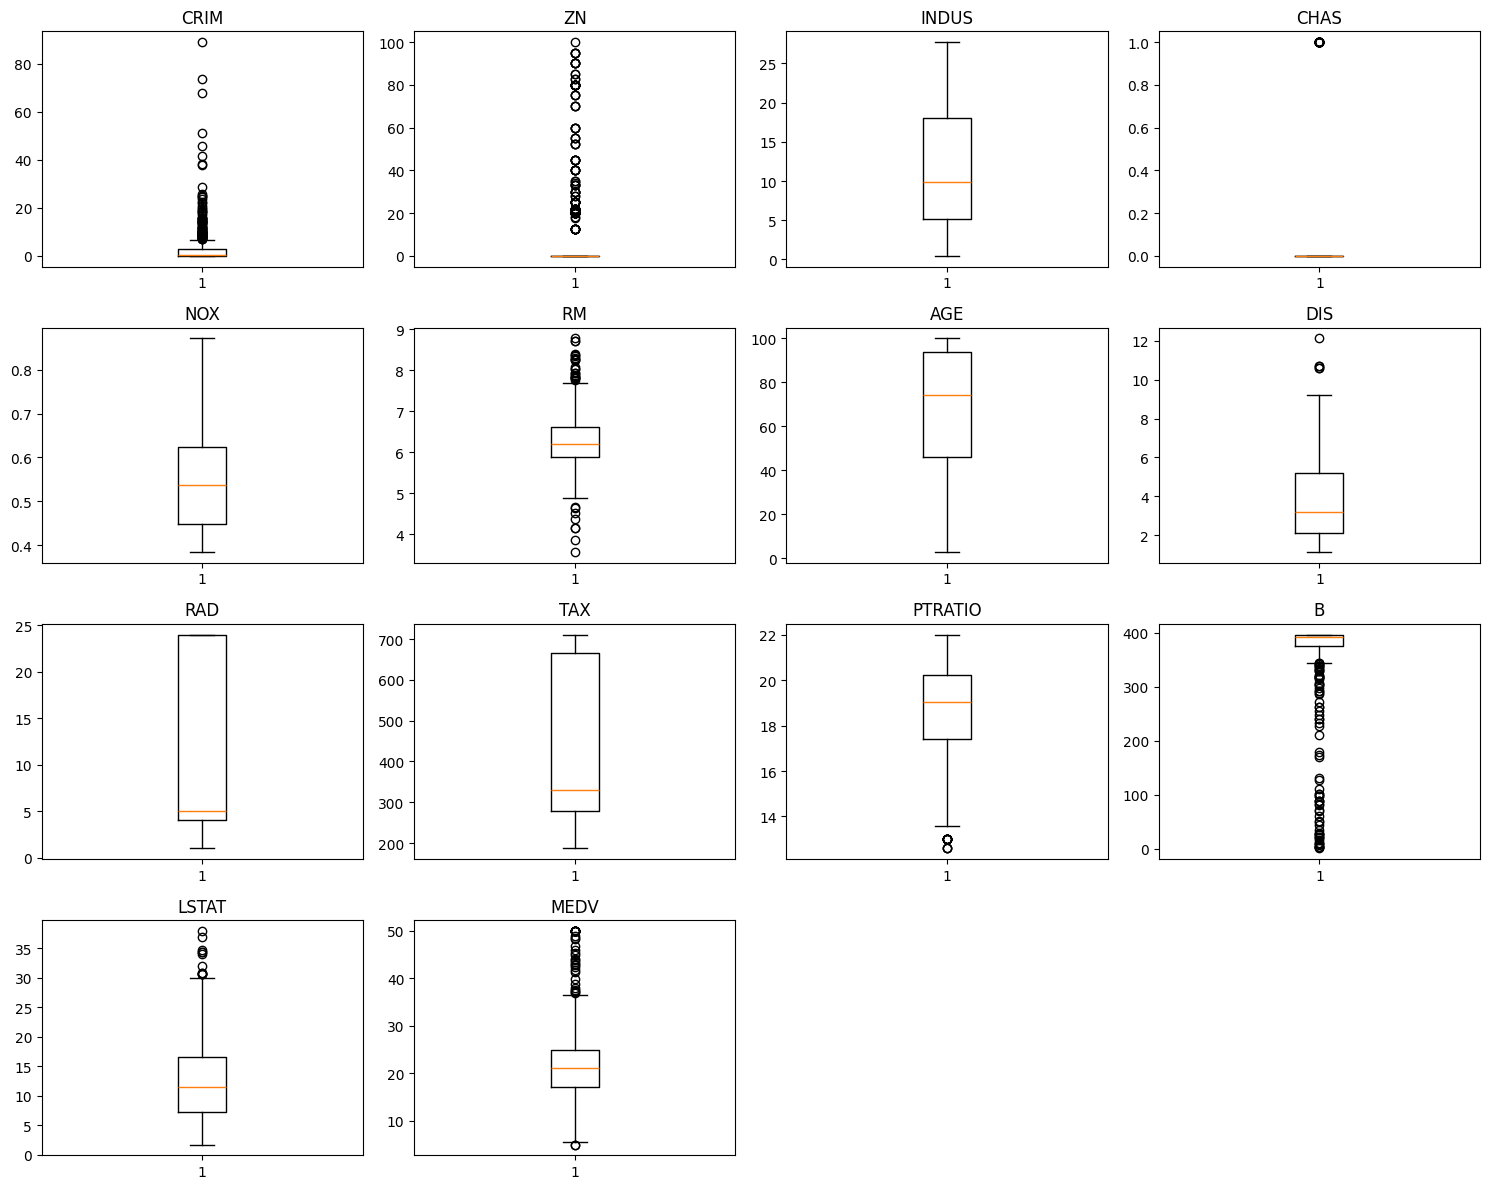

In [120]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))

for i, column in enumerate(df.columns):
    axes.flatten()[i].boxplot(df[column])
    axes.flatten()[i].set_title(column)

for i in range(len(df.columns), 16):
    axes.flatten()[i].set_visible(False)

plt.tight_layout()
plt.savefig('/content/features_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

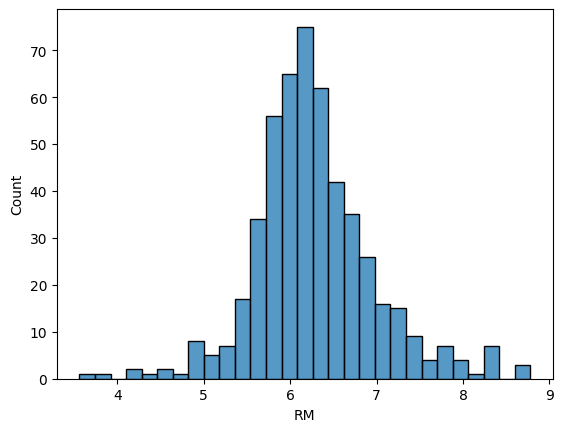

In [119]:
sns.histplot(data=df,x=df['RM'])
plt.savefig('/content/RM_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

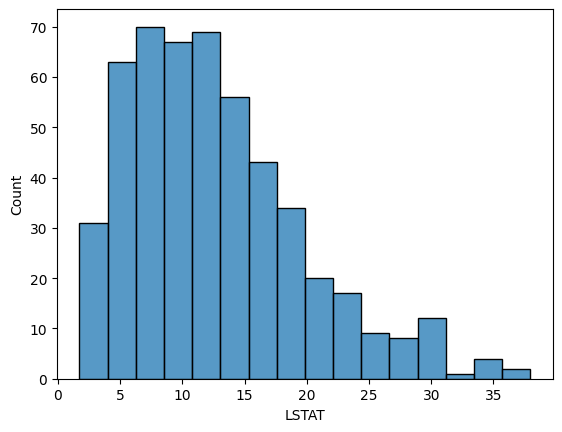

In [118]:
sns.histplot(data=df,x=df['LSTAT'])
plt.savefig('/content/LSTAT_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

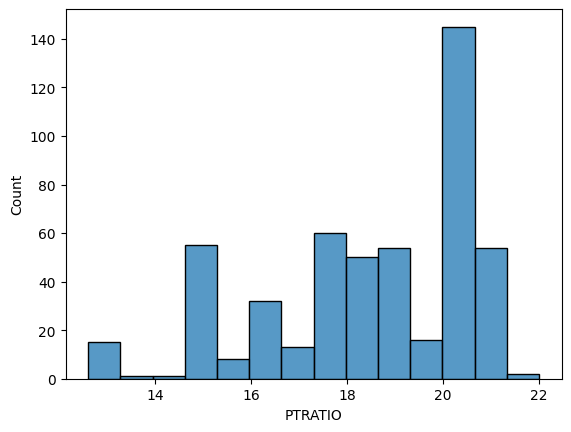

In [117]:
sns.histplot(data=df,x=df['PTRATIO'])
plt.savefig('/content/PTRATIO_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [115]:
for i in plt.get_fignums():
    fig = plt.figure(i)
    fig.savefig(f"figure_{i}.png", dpi=300, bbox_inches='tight')

In [116]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'HousingData.csv', 'sample_data']


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [89]:
X=df.drop('MEDV',axis=1)
y=df['MEDV']

In [90]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [91]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [92]:
m1=LinearRegression()
m1.fit(X_train_scaled,y_train)
y_pred1=m1.predict(X_test_scaled)

m2=DecisionTreeRegressor()
m2.fit(X_train,y_train)
y_pred2=m2.predict(X_test)

m3=KNeighborsRegressor()
m3.fit(X_train_scaled,y_train)
y_pred3=m3.predict(X_test_scaled)

In [93]:
results=[]
model={
    'LinearRegression':m1,
    'DecisionTreeRegressor':m2,
    'KNeighborsRegressor':m3
}
predictions={
    'LinearRegression':y_pred1,
    'DecisionTreeRegressor':y_pred2,
    'KNeighborsRegressor':y_pred3
}
for name in model:
  results.append([
      name,
      mean_absolute_error(y_test,predictions[name]),
      r2_score(y_test,predictions[name]),
      mean_squared_error(y_test,predictions[name]),
      np.sqrt(mean_squared_error(y_test,predictions[name])),
  ])


In [94]:
combined_df=pd.DataFrame(results,columns=['Model','MAE','R2','MSE','RMSE'])
combined_df.sort_values('RMSE',ascending=True)

,Model,MAE,R2,MSE,RMSE
1,DecisionTreeRegressor,2.850980,0.811033,13.857647,3.722586
2,KNeighborsRegressor,2.743725,0.696526,22.254867,4.717506
0,LinearRegression,3.153911,0.658706,25.028378,5.002837


The Decision Tree Regressor performed the best among the three models. It achieved the lowest MAE, MSE, and RMSE, while obtaining the highest R² score of 0.811. This indicates that the Decision Tree model provides the most accurate predictions for the Boston Housing dataset among the models evaluated.

R² = 0.811 means the model explains about 82.7% of the variation in the target values, which is substantially better than KNN (69.7%) and Linear Regression (65.9%).